<a href="https://colab.research.google.com/github/sshafaa/UTS-Data-Mining-2304020007/blob/main/UTS_Data_Mining_Shafa'_Salsabila_2304020007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Persiapan Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data_training = pd.read_csv('data_training.csv')
data_training

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [4]:
data_testing = pd.read_csv('data_testing.csv')
data_testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


2. Pembersihan Data

In [7]:
print(data_training.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


In [8]:
print(data_training.describe())
print(data_training.isnull().sum())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     857.000000        857.000000   857.000000      857.000000   
mean        8.261960          0.529393     0.267351        2.506184   
std         1.701992          0.179162     0.195144        1.293512   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.395000     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.600000          1.580000     1.000000       15.500000   

        chlorides  free sulfur dioxide  total sulfur dioxide     density  \
count  857.000000           857.000000            857.000000  857.000000   
mean     0.086830            15.782964             45.978413    0.996692   
std      0.048721            10.300402             31.692113    0.001901   
min      0.012000             1.000000              6.00

3. Pembuatan Model

In [9]:
x = data_training.drop(['quality','Id'], axis=1)
y = data_training['quality']

x_test_final=data_testing.drop(['Id'], axis=1)

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
test_scaled = scaler.transform(x_test_final)

KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_scaled, y_train)

y_pred_knn = knn.predict(x_val_scaled)

print("Akurasi KNN:", accuracy_score(y_val, y_pred_knn))
print(classification_report(y_val, y_pred_knn))

Akurasi KNN: 0.6395348837209303
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.77      0.71        73
           6       0.63      0.59      0.61        68
           7       0.64      0.64      0.64        22
           8       0.00      0.00      0.00         3

    accuracy                           0.64       172
   macro avg       0.32      0.33      0.33       172
weighted avg       0.61      0.64      0.62       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
cm_knn = confusion_matrix(y_val, y_pred_knn)

print("Confusion Matrix KNN:")
print(cm_knn)

Confusion Matrix KNN:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  2 56 15  0  0]
 [ 0  0 21 40  7  0]
 [ 0  0  1  7 14  0]
 [ 0  0  2  0  1  0]]


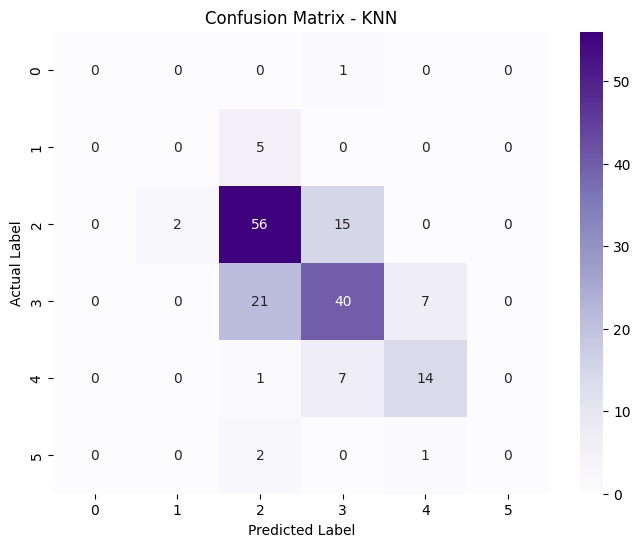

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - KNN')

plt.show()

Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_val_scaled)

print("Akurasi Logistic Regression:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

Akurasi Logistic Regression: 0.6104651162790697
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.73      0.71        73
           6       0.57      0.59      0.58        68
           7       0.52      0.55      0.53        22
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.30      0.31      0.30       172
weighted avg       0.58      0.61      0.60       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
cm_lr = confusion_matrix(y_val, y_pred_lr)

print("Confusion Matrix Logistic Regression:")
print(cm_lr)

Confusion Matrix Logistic Regression:
[[ 0  0  1  0  0  0]
 [ 0  0  4  1  0  0]
 [ 0  2 53 18  0  0]
 [ 0  0 19 40  9  0]
 [ 0  0  0 10 12  0]
 [ 0  0  0  1  2  0]]


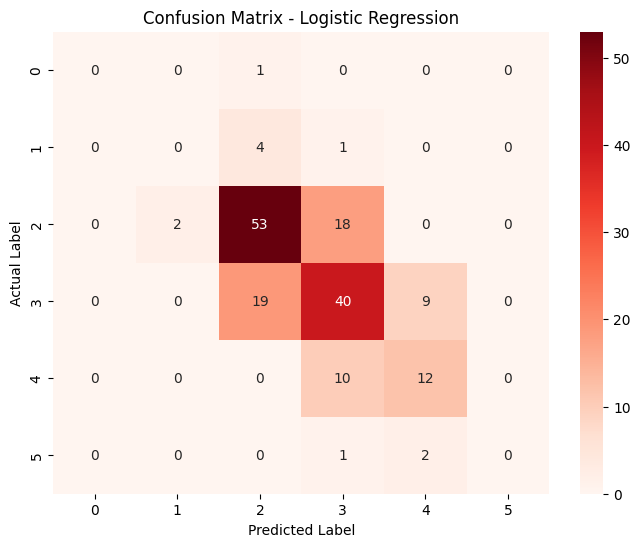

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

SVM

In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm = SVC(kernel='rbf')

svm.fit(x_train_scaled, y_train)

y_pred_svm = svm.predict(x_val_scaled)

print("Akurasi SVM:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

Akurasi SVM: 0.6337209302325582
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.78      0.74        73
           6       0.58      0.63      0.61        68
           7       0.53      0.41      0.46        22
           8       0.00      0.00      0.00         3

    accuracy                           0.63       172
   macro avg       0.30      0.30      0.30       172
weighted avg       0.60      0.63      0.61       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
cm_svm = confusion_matrix(y_val, y_pred_svm)

print("Confusion Matrix SVM:")
print(cm_svm)

Confusion Matrix SVM:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 57 16  0  0]
 [ 0  0 19 43  6  0]
 [ 0  0  0 13  9  0]
 [ 0  0  0  1  2  0]]


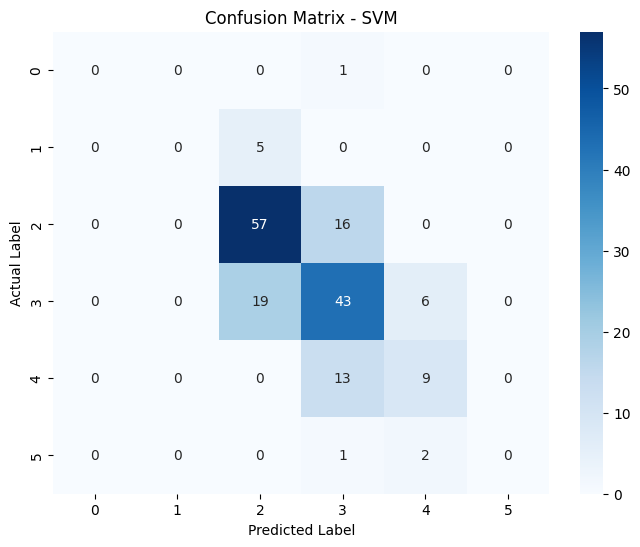

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - SVM')

plt.show()

Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(x_train_scaled, y_train)

y_pred_rf = rf.predict(x_val_scaled)

print("Akurasi Random Forest:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Akurasi Random Forest: 0.872093023255814
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         1
           4       1.00      0.80      0.89         5
           5       0.87      0.90      0.89        73
           6       0.86      0.84      0.85        68
           7       0.87      0.91      0.89        22
           8       1.00      0.67      0.80         3

    accuracy                           0.87       172
   macro avg       0.93      0.85      0.89       172
weighted avg       0.87      0.87      0.87       172



In [40]:
cm_rf = confusion_matrix(y_val, y_pred_rf)

print("Confusion Matrix Random Forest:")
print(cm_rf)

Confusion Matrix Random Forest:
[[ 1  0  0  0  0  0]
 [ 0  4  1  0  0  0]
 [ 0  0 66  7  0  0]
 [ 0  0  9 57  2  0]
 [ 0  0  0  2 20  0]
 [ 0  0  0  0  1  2]]


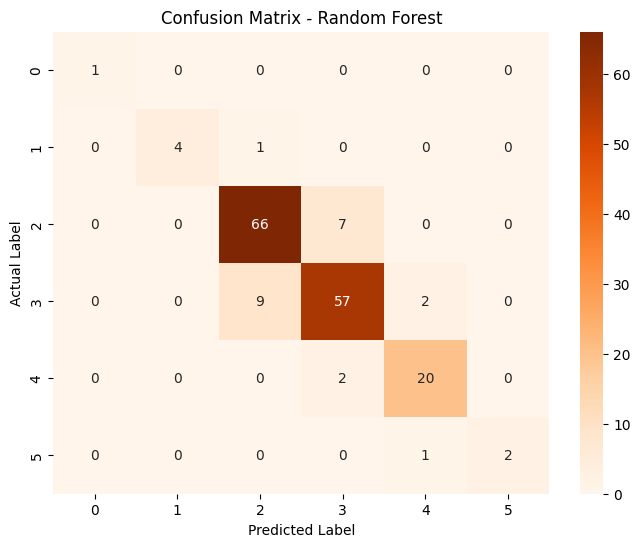

In [52]:
labels = sorted(y.unique())
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_val)

print("Akurasi Decision Tree:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Akurasi Decision Tree: 0.8546511627906976
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         1
           4       0.67      0.80      0.73         5
           5       0.90      0.85      0.87        73
           6       0.86      0.84      0.85        68
           7       0.81      0.95      0.88        22
           8       0.50      0.67      0.57         3

    accuracy                           0.85       172
   macro avg       0.79      0.85      0.82       172
weighted avg       0.86      0.85      0.86       172



In [49]:
cm_dt = confusion_matrix(y_val, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[ 1  0  0  0  0  0]
 [ 0  4  0  0  0  1]
 [ 0  2 62  8  1  0]
 [ 0  0  7 57  3  1]
 [ 0  0  0  1 21  0]
 [ 0  0  0  0  1  2]]


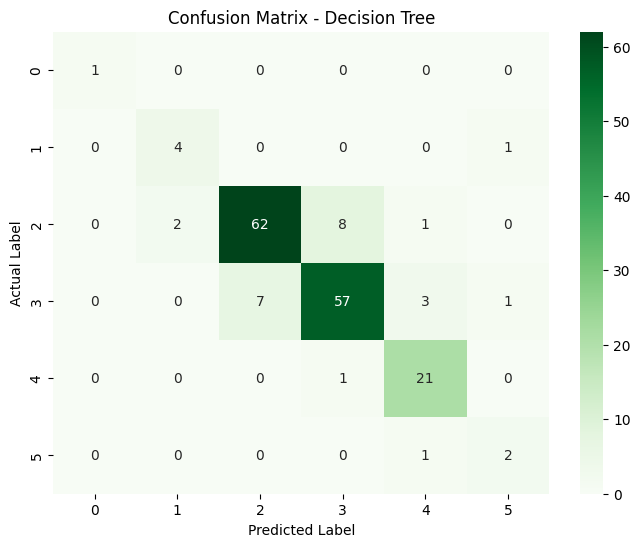

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Decision Tree')

plt.show()

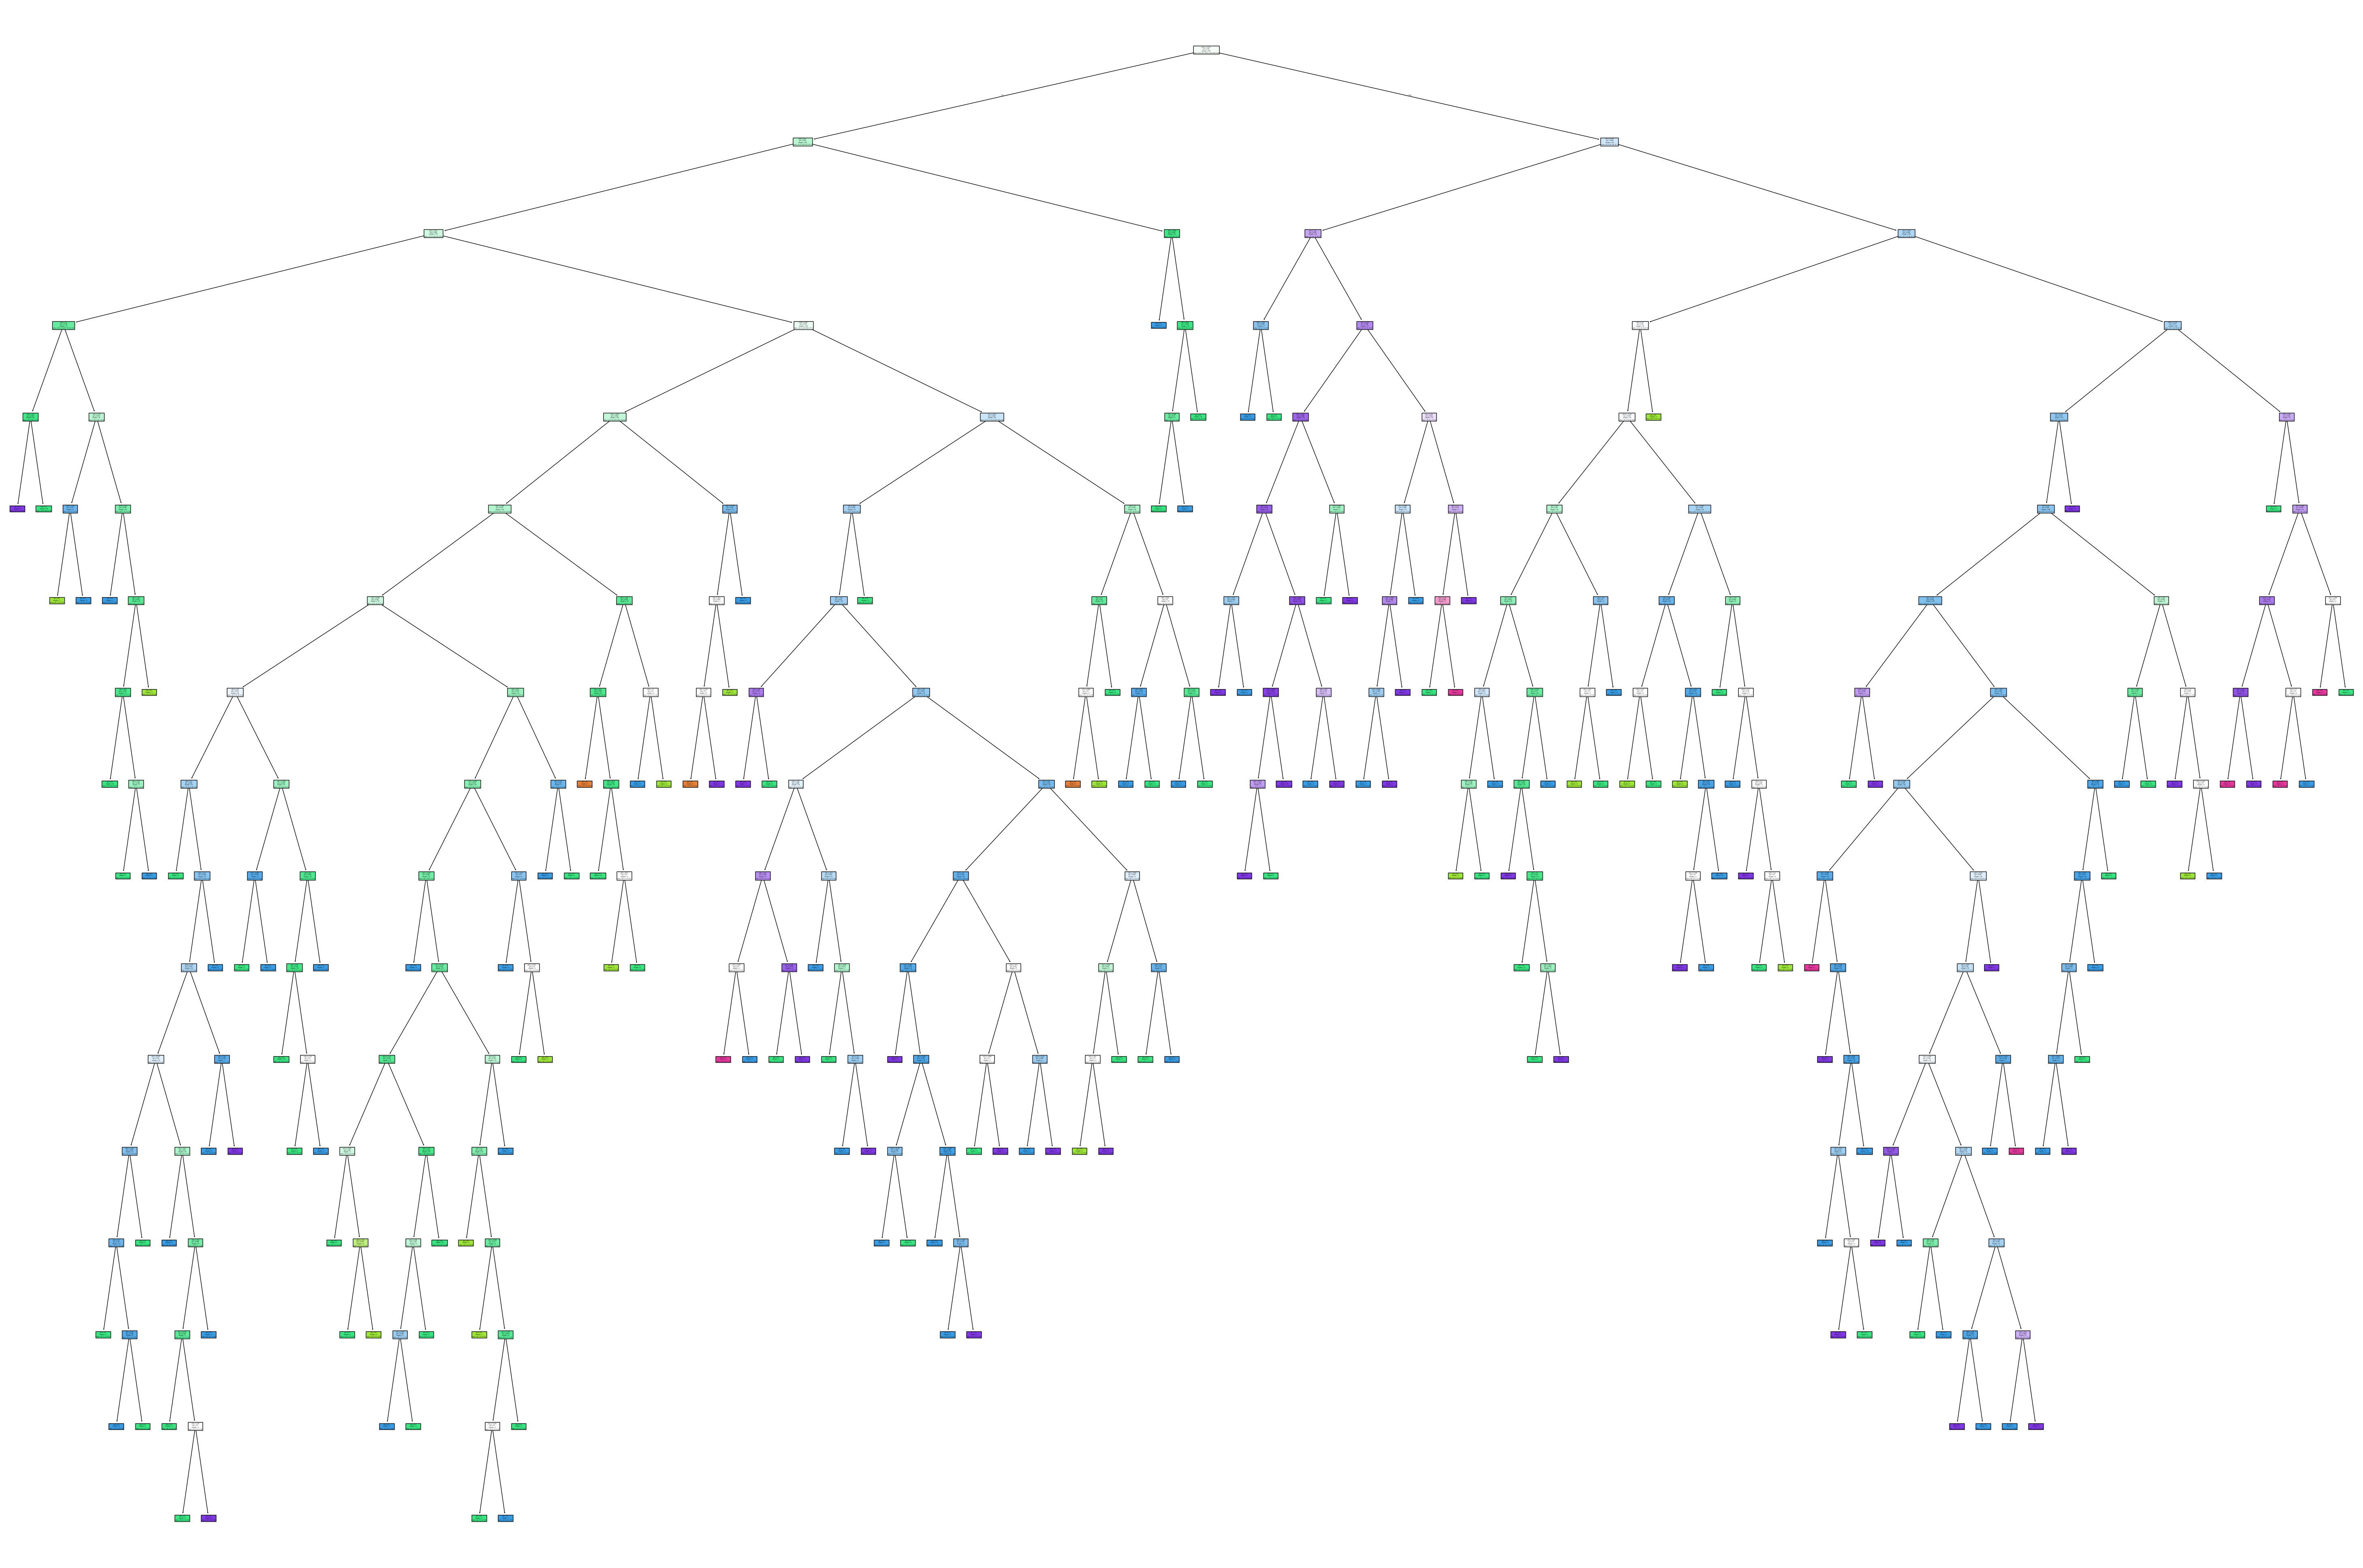

In [51]:
from sklearn.tree import plot_tree
plt.figure(figsize = (75,50))
plot_tree(dt.fit(x_train, y_train), filled=True)
plt.show()

Membandingkan Akurasi Model

In [53]:
akurasi_lr = accuracy_score(y_val, y_pred_lr)
akurasi_knn = accuracy_score(y_val, y_pred_knn)
akurasi_svm = accuracy_score(y_val, y_pred_svm)
akurasi_rf = accuracy_score(y_val, y_pred_rf)
akurasi_dt = accuracy_score(y_val, y_pred_dt)

hasil_model = pd.DataFrame({'Model': ['Logistic Regression', 'KNN', 'SVM', 'Random Forest', 'Decision Tree'], 'Akurasi': [akurasi_lr, akurasi_knn, akurasi_svm, akurasi_rf, akurasi_dt]})

hasil_model

,Model,Akurasi
0,Logistic Regression,0.610465
1,KNN,0.639535
2,SVM,0.633721
3,Random Forest,0.872093
4,Decision Tree,0.854651


Model terbaik adalah Random Forest

Menggunakan Model Terbaik

In [55]:
model_terbaik = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_terbaik.fit(scaler.transform(x), y)

RandomForestClassifier(class_weight='balanced', random_state=42)

4. Prediksi Hasil

In [57]:
prediksi_quality = model_terbaik.predict(test_scaled)
hasil_prediksi = pd.DataFrame({'Id': data_testing['Id'],'quality': prediksi_quality})

hasil_prediksi

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,6


In [58]:
hasil_prediksi.to_csv('hasilprediksi_007.csv', index=False)